# Detekcija anomalija u financijskim transakcijama: duboki autoenkoder

Ova bilježnica implementira i evaluira duboki autoenkoder (engl. *Autoencoder*) za detekciju prijevarnih transakcija, korištenjem skupa podataka Credit Card Fraud Detection (ULB, Kaggle) te biblioteke PyTorch.

Struktura prati poglavlje 4.5. završnog rada *Izrada prototipa sustava za detekciju anomalija u financijskim sustavima u stvarnom vremenu primjenom metoda strojnog učenja*. Kronološka podjela podataka i metrike evaluacije usklađene su s bilježnicom za algoritam izolacijskih stabala radi izravne usporedbe rezultata (poglavlje 4.6.).

In [1]:
#!pip install -q kagglehub scikit-learn pandas matplotlib seaborn
!pip install -q torch

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Koristi se uređaj: {device}")

Koristi se uređaj: cpu


## 1. Učitavanje podataka

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

df = pd.read_csv(f"{path}/creditcard.csv")
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Predobrada podataka

Kao i kod algoritma izolacijskih stabala, Time i Amount skaliramo, a podjelu na trening i test skup provodimo kronološki. Ključna razlika: trening skup sadrži isključivo legitimne transakcije (Class = 0), u skladu s polunadziranim pristupom (autoenkoder uči rekonstruirati samo normalno ponašanje), pa transakcije koje ne uspije vjerno rekonstruirati tretiramo kao potencijalne anomalije.

In [3]:
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

In [4]:
amount_scaler = RobustScaler()
train_df['Amount_scaled'] = amount_scaler.fit_transform(train_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

time_scaler = RobustScaler()
train_df['Time_scaled'] = time_scaler.fit_transform(train_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

In [5]:
X_train_normal = train_df[train_df['Class'] == 0][feature_cols].values.astype(np.float32)

val_split = int(len(X_train_normal) * 0.9)
X_train = X_train_normal[:val_split]
X_val = X_train_normal[val_split:]

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['Class'].values

print(f"Train (just legitimate): {X_train.shape}")
print(f"Validation (just legitimate): {X_val.shape}")
print(f"Test (both classes): {X_test.shape}, Fraud rate: {y_test.mean() * 100:.4f} %")

Train (just legitimate): (179082, 30)
Validation (just legitimate): (19898, 30)
Test (both classes): (85443, 30), Fraud rate: 0.1264 %


## 3. Dataset i DataLoader

PyTorch zahtijeva eksplicitnu definiciju razreda skupa podataka i učitavača (engl. *data loader*), za razliku od Keras-a gdje model.fit() prihvaća NumPy nizove izravno.

In [6]:
class TransactionDataset(Dataset):
    def __init__(self, data):
        self.data = torch.from_numpy(data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

train_loader = DataLoader(TransactionDataset(X_train), batch_size=256, shuffle=True)
val_loader = DataLoader(TransactionDataset(X_val), batch_size=256, shuffle=False)

## 4. Arhitektura autoenkodera

Simetrična arhitektura enkoder – usko grlo – dekoder. Ulazna dimenzija odgovara broju značajki (30: V1–V28, Amount_scaled, Time_scaled).

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20), nn.ReLU(),
            nn.Linear(20, 14), nn.ReLU(),
            nn.Linear(14, 8), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 14), nn.ReLU(),
            nn.Linear(14, 20), nn.ReLU(),
            nn.Linear(20, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

input_dim = X_train.shape[1]
model = Autoencoder(input_dim).to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=14, bias=True)
    (3): ReLU()
    (4): Linear(in_features=14, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=14, bias=True)
    (1): ReLU()
    (2): Linear(in_features=14, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=30, bias=True)
  )
)


## 5. Treniranje

Ručno implementirana petlja treniranja s ranim zaustavljanjem (engl. *early stopping*) prema validacijskom gubitku (u Kerasu ovo obavlja callbacks.EarlyStopping, u PyTorchu se piše
eksplicitno).

Epoch 1/50 - train: 0.824916 - validation: 0.743973
Epoch 2/50 - train: 0.536888 - validation: 0.661376
Epoch 3/50 - train: 0.475411 - validation: 0.603972
Epoch 4/50 - train: 0.438966 - validation: 0.554009
Epoch 5/50 - train: 0.408480 - validation: 0.519900
Epoch 6/50 - train: 0.388687 - validation: 0.502277
Epoch 7/50 - train: 0.375710 - validation: 0.485546
Epoch 8/50 - train: 0.365069 - validation: 0.469305
Epoch 9/50 - train: 0.354572 - validation: 0.463730
Epoch 10/50 - train: 0.345616 - validation: 0.452776
Epoch 11/50 - train: 0.338515 - validation: 0.450559
Epoch 12/50 - train: 0.333000 - validation: 0.439215
Epoch 13/50 - train: 0.328001 - validation: 0.442870
Epoch 14/50 - train: 0.324153 - validation: 0.434561
Epoch 15/50 - train: 0.321155 - validation: 0.432032
Epoch 16/50 - train: 0.318177 - validation: 0.428317
Epoch 17/50 - train: 0.315836 - validation: 0.428019
Epoch 18/50 - train: 0.313503 - validation: 0.426756
Epoch 19/50 - train: 0.311666 - validation: 0.419786
Ep

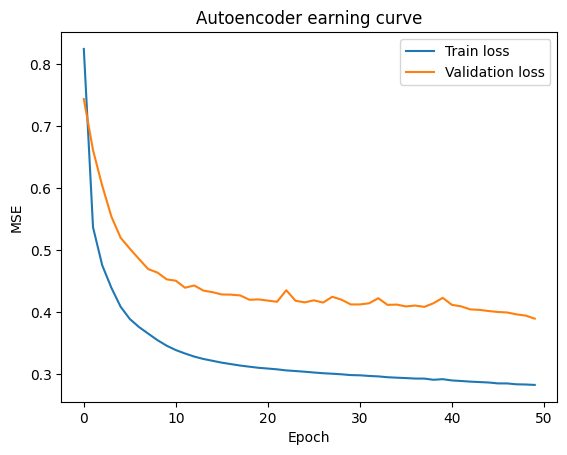

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

n_epochs = 50
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    epoch_train_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstruction = model(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch.size(0)
    epoch_train_loss /= len(train_loader.dataset)

    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            reconstruction = model(batch)
            loss = criterion(reconstruction, batch)
            epoch_val_loss += loss.item() * batch.size(0)
    epoch_val_loss /= len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch + 1}/{n_epochs} - train: {epoch_train_loss:.6f} - validation: {epoch_val_loss:.6f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping after epoch {epoch + 1}.")
            break

model.load_state_dict(best_state)

plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Autoencoder earning curve')
plt.legend()
plt.show()

## 6. Pogreška rekonstrukcije i određivanje praga

Prag postavljamo na temelju percentila pogreške rekonstrukcije na validacijskom skupu, koji sadrži isključivo legitimne transakcije (npr. 99. percentil znači da otprilike 1 % legitimnih transakcija u validaciji prelazi prag). To je polazna točka koju je moguće dodatno podešavati ovisno o željenom odnosu preciznosti i odziva.

In [9]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test).to(device)
    X_test_pred = model(X_test_tensor).cpu().numpy()

    X_val_tensor = torch.from_numpy(X_val).to(device)
    X_val_pred = model(X_val_tensor).cpu().numpy()

reconstruction_error = np.mean(np.square(X_test - X_test_pred), axis=1)
val_error = np.mean(np.square(X_val - X_val_pred), axis=1)

threshold = np.percentile(val_error, 99)
print(f"Reconstruction error threshold: {threshold:.4f}")

y_pred = (reconstruction_error > threshold).astype(int)

Reconstruction error threshold: 1.7552


## 7. Evaluacija

Precision: 0.1067
Recall: 0.7778
F1-score: 0.1877
ROC-AUC: 0.9541
PR-AUC: 0.2156


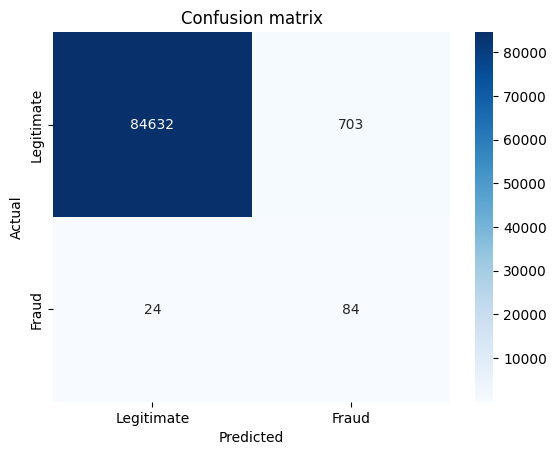

In [10]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, reconstruction_error)
pr_auc = average_precision_score(y_test, reconstruction_error)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

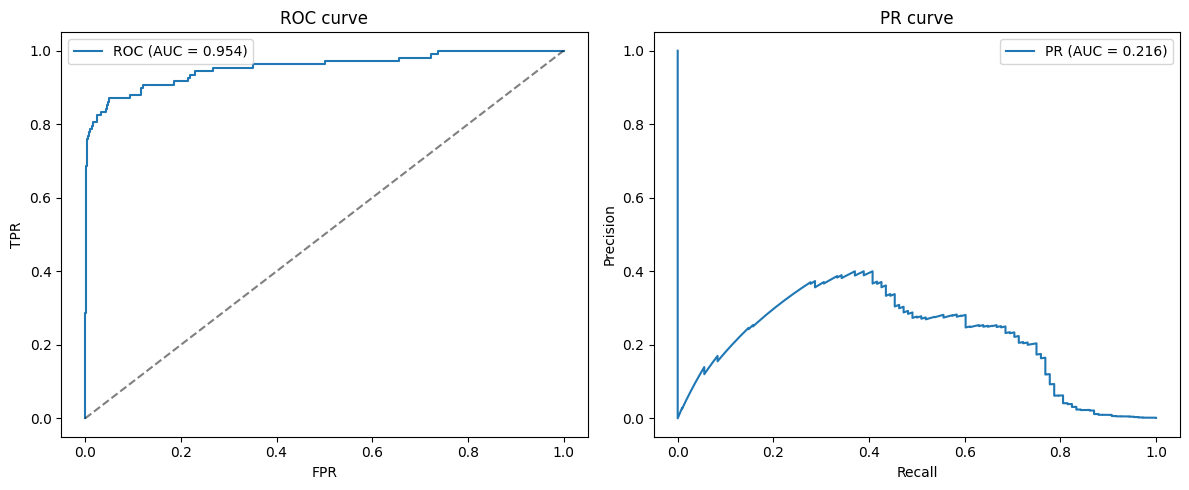

In [11]:
fpr, tpr, _ = roc_curve(y_test, reconstruction_error)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, reconstruction_error)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f'PR (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()
plt.tight_layout()
plt.show()

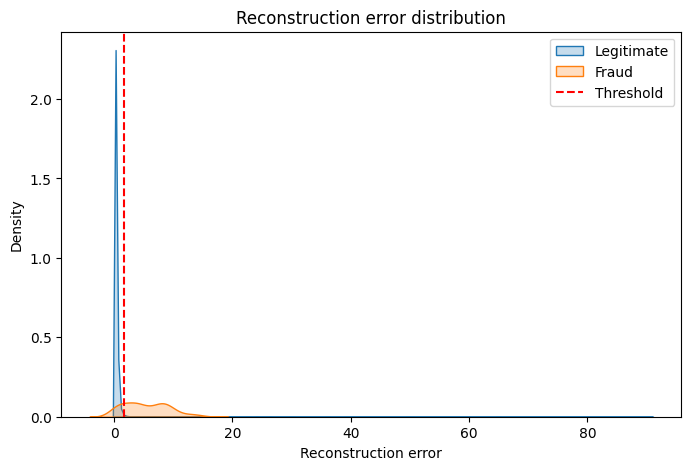

In [12]:
plt.figure(figsize=(8, 5))
sns.kdeplot(reconstruction_error[y_test == 0], label='Legitimate', fill=True)
sns.kdeplot(reconstruction_error[y_test == 1], label='Fraud', fill=True)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Reconstruction error')
plt.title('Reconstruction error distribution')
plt.legend()
plt.show()

## 8. Vizualizacija naučene reprezentacije (2D usko grlo)

Kako bismo intuitivno prikazali što autoenkoder uči, treniramo zaseban, ilustrativni autoenkoder s uskim grlom veličine samo 2 neurona (za razliku od stvarnog modela čije je usko grlo veličine 8). Ovo je isključivo u svrhu vizualizacije, odvojeno od modela korištenog za stvarnu evaluaciju. Nakon treniranja se primjenjuje samo enkoderski dio na testne podatke, čime se dobiva njihova 2D reprezentacija, prikazana u ravnini obojena prema stvarnoj klasi.

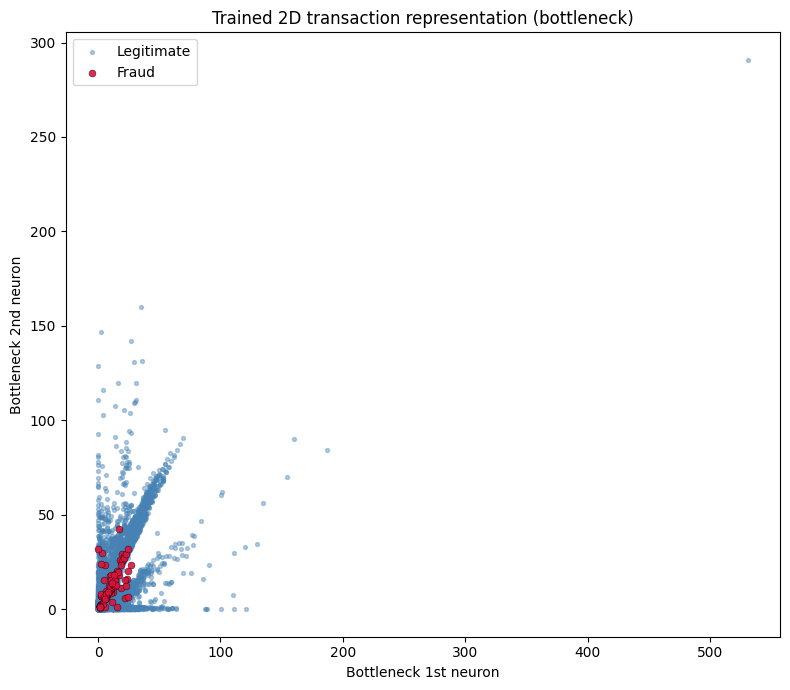

In [13]:
class Autoencoder2DViz(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20), nn.ReLU(),
            nn.Linear(20, 14), nn.ReLU(),
            nn.Linear(14, 2), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 14), nn.ReLU(),
            nn.Linear(14, 20), nn.ReLU(),
            nn.Linear(20, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

viz_model = Autoencoder2DViz(input_dim).to(device)
viz_criterion = nn.MSELoss()
viz_optimizer = torch.optim.Adam(viz_model.parameters())
viz_train_loader = DataLoader(TransactionDataset(X_train), batch_size=256, shuffle=True)

viz_model.train()
for epoch in range(15):
    for batch in viz_train_loader:
        batch = batch.to(device)
        viz_optimizer.zero_grad()
        reconstruction = viz_model(batch)
        loss = viz_criterion(reconstruction, batch)
        loss.backward()
        viz_optimizer.step()

viz_model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test).to(device)
    X_test_2d = viz_model.encoder(X_test_tensor).cpu().numpy()

plt.figure(figsize=(8, 7))
plt.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1],
            c='steelblue', s=8, alpha=0.4, label='Legitimate')
plt.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1],
            c='crimson', s=25, alpha=0.9, label='Fraud', edgecolors='k', linewidths=0.3)
plt.xlabel('Bottleneck 1st neuron')
plt.ylabel('Bottleneck 2nd neuron')
plt.title('Trained 2D transaction representation (bottleneck)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Spremanje modela

In [14]:
torch.save(model.state_dict(), 'autoencoder_pytorch_model.pt')
print("Model spremljen.")

Model spremljen.
